C:\Users\Shuyang Yao\AppData\Local\Temp\ipykernel_23268\3193918924.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


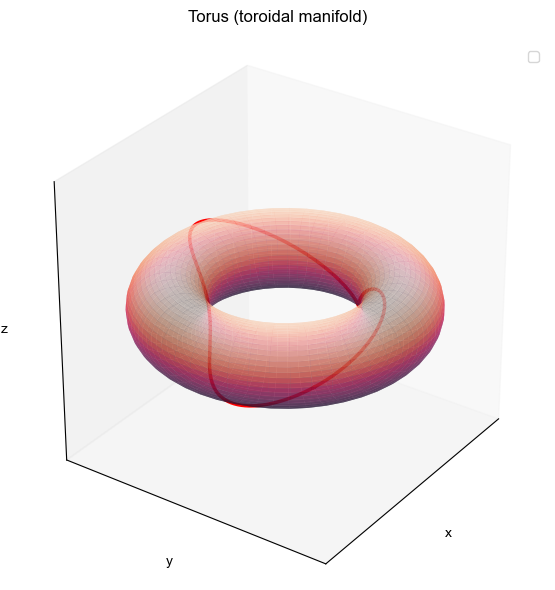

In [141]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # just to register 3D projection
import seaborn as sns


def torus(R=2.0, r=0.7, nu=100, nv=100):
    """
    Generate the (x,y,z) coords of a torus embedded in R^3.

    A torus can be parameterized by two angles:
        u \in [0, 2π)  (goes around the "tube")
        v \in [0, 2π)  (goes around the "hole")

    Embedding:
        x(u,v) = (R + r cos u) cos v
        y(u,v) = (R + r cos u) sin v
        z(u,v) = r sin u

    Args
    ----
    R : float
        Major radius (distance from center of hole to center of tube)
    r : float
        Minor radius (radius of the tube)
    nu : int
        Number of samples along u
    nv : int
        Number of samples along v

    Returns
    -------
    X, Y, Z : np.ndarray shape (nu, nv)
        Meshgrid of coordinates for plotting
    """

    u = np.linspace(0, 2 * np.pi, nu)
    v = np.linspace(0, 2 * np.pi, nv)
    u, v = np.meshgrid(u, v, indexing="ij")

    X = (R + r * np.cos(u)) * np.cos(v)
    Y = (R + r * np.cos(u)) * np.sin(v)
    Z = r * np.sin(u)

    return X, Y, Z

def torus_curve(R, r, phi, theta, n_pts=500):
    """
    Generate a curve on the torus defined by θ = k * φ + b.

    We'll treat φ = t and θ = k*t + b.
    We then embed (θ, φ) into R^3 using the same torus parameterization.

    Args
    ----
    R, r : torus radii
    k, b : curve definition θ = k*φ + b
    n_pts : number of samples along the curve
    t_min, t_max : range of φ values we trace

    Returns
    -------
    xline, yline, zline : (n_pts,) arrays
    """

    xline = (R + r * np.cos(theta)) * np.cos(phi)
    yline = (R + r * np.cos(theta)) * np.sin(phi)
    zline = r * np.sin(theta)

    return xline, yline, zline

def plot_torus(R=2.0, r=0.7, nu=200, nv=200,
               elev=30, azim=35, cmap="viridis"):
    """
    Make a pretty 3D surface plot of a torus.
    elev / azim control camera angle.
    """

    X, Y, Z = torus(R, r, nu, nv)

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    # surface
    
    surf = ax.plot_surface(
        X, Y, Z,
        linewidth=0,
        antialiased=True,
        cmap=cmap,   # you can try "plasma", "magma", etc.
        alpha=0.6,
        rstride=1,
        cstride=1,
    )
    theta = np.linspace(0, 4 * np.pi, 1000)
    phi = 0.5 * theta + np.pi / 4  # example: k=0.5, b=π/4
    
    xline, yline, zline = torus_curve(R, r, phi, theta)
    ax.plot(
        xline,
        yline,
        zline,
        linewidth=2.5,
        color="red"   # highlight the geodesic-like stripe
    )
    ax.legend()
    

    # nice equal-ish aspect
    max_range = np.array([
        X.max() - X.min(),
        Y.max() - Y.min(),
        Z.max() - Z.min()
    ]).max() / 2.0

    mid_x = (X.max() + X.min()) * 0.5
    mid_y = (Y.max() + Y.min()) * 0.5
    mid_z = (Z.max() + Z.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    # cosmetic stuff
    ax.set_box_aspect([1, 1, 1])  # requires newer matplotlib
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Torus (toroidal manifold)", pad=16)

    # camera angle
    ax.view_init(elev=elev, azim=azim)

    # add colorbar
    #fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, pad=0.05,
    #             label="Minor-angle (u) height / colormap")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # Try different shapes:
    #   - donut: R=2, r=0.7
    #   - "fat donut": R=1.5, r=1.2
    #   - "thin ring": R=3, r=0.4
    plot_torus(R=2.0, r=0.7, cmap='rocket', nu=50, nv=50)



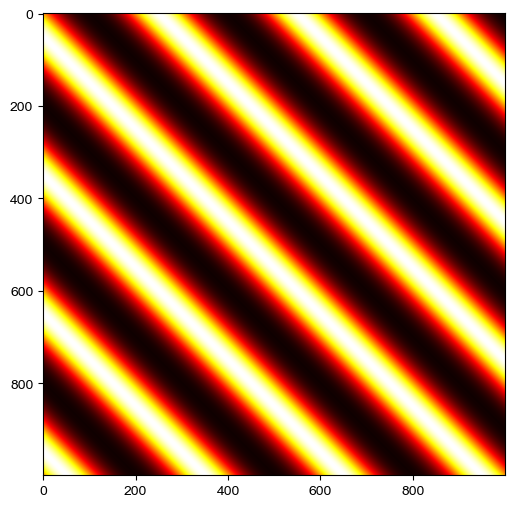

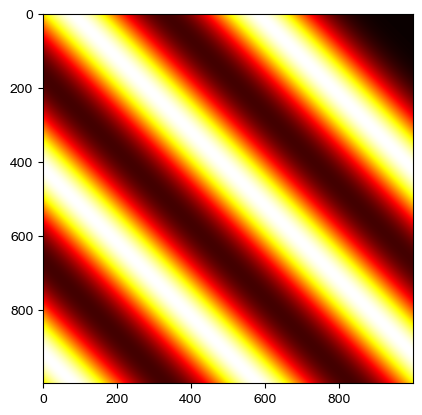

In [ ]:
N = 1000
x = np.linspace(0, 1, N)
y = np.zeros((N, N))
y = (
    np.exp(-(np.tile(x, (N, 1)) - x[:, np.newaxis] + 0.05)**2 / 0.005) + 
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.3)+ 0.05)**2 / 0.005) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.6)+ 0.05)**2 / 0.005) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.9)+ 0.05)**2 / 0.005) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.3)+ 0.05)**2 / 0.005) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.6)+ 0.05)**2 / 0.005) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.9)+ 0.05)**2 / 0.005)
)
y /= np.max(y, axis=1, keepdims=True)
plt.figure(figsize=(6, 6))

y2 = (
    np.exp(-(np.tile(x, (N, 1)) - x[:, np.newaxis] + 0.42)**2 / 0.02) + 
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.5) + 0.42)**2 / 0.02) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 1) + 0.42)**2 / 0.02) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.5) + 0.42)**2 / 0.02) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 1) + 0.42)**2 / 0.02)
)
y2 /= np.max(y2, axis=1, keepdims=True)

y3 = (
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis]) + 0.11)**2 / 0.002) + 
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.2) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.4) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.6) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 0.8) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] + 1) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.2) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.4) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.6) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 0.8) + 0.11)**2 / 0.002) +
    np.exp(-(np.tile(x, (N, 1)) - (x[:, np.newaxis] - 1) + 0.11)**2 / 0.002)
)
y3 /= np.max(y3, axis=1, keepdims=True)
    
s = np.exp(-(np.tile(x, (N, 1)) - x[:, np.newaxis])**2 / 0.01)
s /= np.max(s, axis=1, keepdims=True)

ax = plt.axes()
ax.imshow(y, aspect='auto', cmap='hot')
ax.set_aspect('equal')
plt.show()

ax = plt.axes()
ax.imshow(y2, aspect='auto', cmap='hot')
ax.set_aspect('equal')
plt.show()

ax = plt.axes()
ax.imshow(y3, aspect='auto', cmap='hot')
ax.set_aspect('equal')
plt.show()

def sigmoid(x):
    return 1 / (1 + np.exp(-5*(x-15)))

def relu(x):
    return np.maximum(0, x)

W1 = np.random.randn(N, N)*0.1
W2 = np.random.randn(N, N)*0.1
W3 = np.random.randn(N, N)*0.1
Ws = np.random.randn(N, N)*0.2

CA3 = sigmoid(W1 @ y + W2 @ y2 + W3 @ y3 + Ws @ s) #
print(CA3.shape)
peak_rate = np.argmax(CA3, axis=1)
order = np.argsort(peak_rate)
CA3 = CA3[order]
CA3 /= np.max(CA3, axis=1, keepdims=True)
plt.imshow(CA3, aspect='auto', cmap='hot')
plt.show()

# Maze Trajectory

In [1]:
from mylib.statistic_test import *
    
template_dir = r"D:\Data\FinalResults\Dsp\0869 - Detailed Behavioral Analysis\template"
with open(join(template_dir, "10232.pkl"), 'rb') as handle:
    template = pickle.load(handle)
    
template_r0 = template[CP_DSP[0][:-1]-1, :, 0]

with open(f2['Trace File'][34], 'rb') as handle:
    trace = pickle.load(handle)

d:\Software\Anaconda3\envs\maze\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


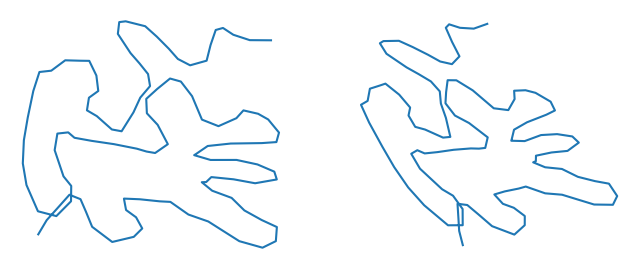

In [2]:
θ = np.pi/12
R = rotate_mat = np.array([
    [np.cos(θ), -np.sin(θ)],
    [np.sin(θ), np.cos(θ)]
])
H = hexogonalize_mat = np.array([
    [1, -np.sqrt(3)/3],
    [0, 2*np.sqrt(3)/3]
])

dx = np.diff(template_r0[:, 0]) + np.random.randn(template_r0.shape[0]-1)*1
dy = np.diff(template_r0[:, 1]) + np.random.randn(template_r0.shape[0]-1)*1
P0 = np.vstack([np.cumsum(dx), np.cumsum(dy)])
P0 = np.concatenate([np.zeros((2, 1)), P0], axis=1)
P0 += template_r0[:1, :2].T
P = H @ (R @ P0)

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(8, 4))
ax0, ax1 = Clear_Axes(axes[0]), Clear_Axes(axes[1])
ax0.plot(P0[0, :], P0[1, :])
ax1.plot(P[0, :], P[1, :])
ax0.set_aspect("equal")
ax1.set_aspect("equal")

In [3]:
beg, end = LapSplit(trace, "DSPMaze")
P = trace['correct_pos'][beg[-1]:end[-1]+1].T

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

class GridModule(object):
    def __init__(
        self, 
        space: float, 
        rotate: float, 
        phase: np.ndarray = np.zeros((2, 1))
    ):                                                                                                                                                                                                                                                       
        self.space = space
        self.R = np.array([
            [np.cos(rotate), -np.sin(rotate)],
            [np.sin(rotate), np.cos(rotate)]
        ])
        self.H = np.array([
            [1, -np.sqrt(3)/3],
            [0, 2*np.sqrt(3)/3]
        ])
        
        assert phase.shape == (2, 1), f"Phase should be in the shape of (2, 1)"
        self.P0 = phase
        
    def convert(self, P: np.ndarray) -> np.ndarray:
        """Convert cartesian coordinates to positions on the neural sheet."""
        Pc = self.H @ (self.R @ P)
        Pc = (Pc + self.P0 * self.space) % self.space
        return Pc
    
    def convert_to_polar(self, P: np.ndarray) -> np.ndarray:
        """Convert cartesian coordiantes to positions on the toroidal manifold."""
        return self.convert(P) / self.space * np.pi * 2
    
    def convert_for_visualization(
        self, P: np.ndarray, R: float, r: float
    ) -> np.ndarray:
        """Convert cartesian coordinates to trajectories on the surface
        of a toroidal manifold.

        Parameters
        ----------
        P : np.ndarray
            Position information, shape (2, T)
        R : float
            Major radius (distance from center of hole to center of tube)
        r : float
            Minor radius (radius of the tube)

        Returns
        -------
        np.ndarray
            The converted coordinates for visualization, shape (3, T)
        """
        P = self.convert_to_polar(P)
        u, v = P[0, :], P[1, :]
        
        X = (R + r * np.cos(u)) * np.cos(v)
        Y = (R + r * np.cos(u)) * np.sin(v)
        Z = r * np.sin(u)

        return np.vstack([X, Y, Z])
    

class PISystem(object):
    def __init__(self):
        self.M1 = GridModule(space=48, **self.rand_module_params())
        self.M2 = GridModule(space=63, **self.rand_module_params())
        self.M3 = GridModule(space=92, **self.rand_module_params())
        self.M4 = GridModule(space=120, **self.rand_module_params())
        
        self.R = 2
        self.r = 0.7
        
    def rand_module_params(self):
        return {
            "rotate": np.random.rand(1)[0]*np.pi*2,
            "phase": np.random.rand(2, 1)
        }

    def torus(self, R=2.0, r=0.7, nu=100, nv=100):
        """
        Generate the (x,y,z) coords of a torus embedded in R^3.

        A torus can be parameterized by two angles:
            u \in [0, 2π)  (goes around the "tube")
            v \in [0, 2π)  (goes around the "hole")

        Embedding:
            x(u,v) = (R + r cos u) cos v
            y(u,v) = (R + r cos u) sin v
            z(u,v) = r sin u

        Args
        ----
        R : float
            Major radius (distance from center of hole to center of tube)
        r : float
            Minor radius (radius of the tube)
        nu : int
            Number of samples along u
        nv : int
            Number of samples along v

        Returns
        -------
        X, Y, Z : np.ndarray shape (nu, nv)
            Meshgrid of coordinates for plotting
        """

        u = np.linspace(0, 2 * np.pi, nu)
        v = np.linspace(0, 2 * np.pi, nv)
        u, v = np.meshgrid(u, v, indexing="ij")

        X = (R + r * np.cos(u)) * np.cos(v)
        Y = (R + r * np.cos(u)) * np.sin(v)
        Z = r * np.sin(u)

        return X, Y, Z
 
    def plot_torus(self):
        fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(8, 8), subplot_kw={'projection': '3d'})
        self.lines = []
        self.ax0, self.ax1, self.ax2, self.ax3 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
        
        for ax, bin_size, module_name, cmap in zip(
            [self.ax0, self.ax1, self.ax2, self.ax3],
            [40, 40, 40, 40],
            [f'Module {i}' for i in range(1, 5)],
            ['rocket', 'Greens', 'Blues', 'Purples']
        ):
            X, Y, Z = self.torus(self.R, self.r, bin_size, bin_size)
            surf = ax.plot_surface(
                X, Y, Z,
                linewidth=0,
                antialiased=True,
                cmap=cmap,   # you can try "plasma", "magma", etc.
                alpha=0.6
            )
            surf.set_zsort("min")
            max_range = np.array([
                X.max() - X.min(),
                Y.max() - Y.min(),
                Z.max() - Z.min()
            ]).max() / 2.0

            mid_x = (X.max() + X.min()) * 0.5
            mid_y = (Y.max() + Y.min()) * 0.5
            mid_z = (Z.max() + Z.min()) * 0.5

            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)
            ax.view_init(elev=30, azim=35)
            ax.set_box_aspect([1, 1, 1])  # requires newer matplotlib
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
            ax.set_title(module_name)
                
    def update_lines(self, P: np.ndarray):
        for item in self.lines:
            item.clear()
        self.lines = []
            
        for grid_module, ax in zip(
            [self.M1, self.M2, self.M3, self.M4],
            [self.ax0, self.ax1, self.ax2, self.ax3]
        ):
            Pc = grid_module.convert_for_visualization(P, self.R, self.r)
            X, Y, Z = Pc[0, :], Pc[1, :], Pc[2, :]
            
            a = ax.plot3D(
                X, Y, Z, linewidth=2, color='red',
                zorder=10
            )
            self.lines += a
            
    def make_figure(self, P: np.ndarray, bins=100):
        # 2x2 3D subplots (each a 'scene')
        fig = make_subplots(
            rows=2, cols=2,
            specs=[[{'type': 'scene'}, {'type': 'scene'}],
                   [{'type': 'scene'}, {'type': 'scene'}]],
            subplot_titles=("Module 1", "Module 2", "Module 3", "Module 4"),
            horizontal_spacing=0.02, vertical_spacing=0.02
        )

        modules = [self.M1, self.M2, self.M3, self.M4]
        targets = [(1,1), (1,2), (2,1), (2,2)]
        colorscales = ["Viridis", "Greens", "Blues", "Purples"]

        for (row, col), mod, cs in zip(targets, modules, colorscales):
            X, Y, Z = self.torus(self.R, self.r, nu=bins, nv=bins)

            # Surface
            fig.add_trace(
                go.Surface(
                    x=X, y=Y, z=Z,
                    showscale=False,
                    opacity=0.65,
                    colorscale=cs,
                    lighting=dict(ambient=0.5, diffuse=0.6, specular=0.2, roughness=0.9),
                    contours=dict(z=dict(show=False)),
                ),
                row=row, col=col
            )

            # Line (trajectory)
            Pc = mod.convert_for_visualization(P, self.R, self.r)
            Xl = Pc[0]
            Yl = Pc[1]
            Zl = Pc[2]

            fig.add_trace(
                go.Scatter3d(
                    x=Xl, y=Yl, z=Zl,
                    mode='lines',
                    line=dict(width=5),
                    name='trajectory',
                ),
                row=row, col=col
            )

            # Scene layout (equal aspect, clean axes)
            scene_key = f"scene{(row-1)*2 + col}"  # scene1..scene4
            fig.update_layout(**{
                scene_key: dict(
                    xaxis=dict(visible=False),
                    yaxis=dict(visible=False),
                    zaxis=dict(visible=False),
                    aspectmode='data',
                    camera=dict(eye=dict(x=1.6, y=1.6, z=1.0))
                )
            })

        fig.update_layout(
            margin=dict(l=0, r=0, t=40, b=0),
            template='plotly_white'
        )
        return fig

model = PISystem()
#model.plot_torus()
#print(P0.shape)
#model.update_lines(P0[:, ])
fig = model.make_figure(P0, bins=120)
fig.show()


100%|██████████| 40/40 [00:03<00:00, 12.33it/s]


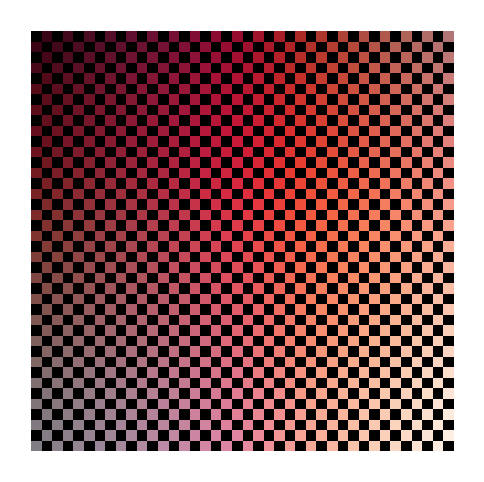

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mylib.statistic_test import *

def diagonal_hued_ratemap(rate, sigma=1.5, cmap_diag='turbo', cmap_anti='magma',
                          brighten=True, vmin=None, vmax=None):
    """
    Color the ratemap so hue follows the two diagonals and brightness follows rate.
    - rate: 2D array
    - sigma: how wide each diagonal's influence is (in pixels); larger = softer blend
    - cmap_diag / cmap_anti: colormap names for the principal and anti-principal diagonals
    - brighten: if True, multiply colors by normalized rate to encode magnitude
    - vmin/vmax: min/max for rate normalization (defaults to data min/max)
    """
    R = np.asarray(rate, dtype=float)
    H, W = R.shape
    y, x = np.mgrid[0:H, 0:W]

    # Distances to the two diagonals
    # principal: y = x; anti-principal: y = -x + (W-1)
    d_princ = np.abs(y - x) / np.sqrt(2)
    d_anti  = np.abs(y + x - (W - 1)) / np.sqrt(2)

    # Soft attention to each diagonal
    w1 = np.exp(-(d_princ**2) / (2*sigma**2))
    w2 = np.exp(-(d_anti**2)  / (2*sigma**2))
    wsum = (w1 + w2 + 1e-12)
    w1, w2 = w1/wsum, w2/wsum

    # Coordinates *along* each diagonal mapped to [0,1]
    # principal runs along (x+y); anti runs along (x - y) (shifted to be positive)
    s_princ = (x + y) / ( (H-1)+(W-1) )  # 0..1 from top-left to bottom-right
    s_anti  = (x - y - (-(H-1))) / ( (W-1) + (H-1) )  # 0..1 from bottom-left to top-right

    C1 = cm.get_cmap(cmap_diag)(s_princ)  # RGBA
    C2 = cm.get_cmap(cmap_anti)(s_anti)   # RGBA

    # Blend the two diagonal color fields by proximity weights
    RGB = (w1[..., None]*C1[..., :3] + w2[..., None]*C2[..., :3])

    # Brightness from firing rate
    if brighten:
        norm = Normalize(vmin if vmin is not None else np.nanmin(R),
                         vmax if vmax is not None else np.nanmax(R), clip=True)
        Rn = norm(R)
        RGB = RGB * (0.15 + 0.85*Rn[..., None])  # avoid fully dark colors at low rate

    return np.clip(RGB, 0, 1)

# --- Example ---
if __name__ == "__main__":
    import seaborn as sns
    
    cmap1 = sns.color_palette("Reds", as_cmap=True)
    cmap2 = sns.color_palette("rocket", as_cmap=True)
    
    x = np.linspace(0, 1-1e-8, 40)
    y = np.linspace(0, 1-1e-8, 40)
    
    x = np.tile(x, (40, 1))
    y = np.tile(y, (40, 1)).T

    colors = (cmap1(x) + cmap2(y)) / 2

    fig = plt.figure(figsize=(6, 6))
    ax = Clear_Axes(plt.axes())
    for i in tqdm(range(colors.shape[0])):
        for j in range(colors.shape[1]):
            if (i % 2 == 0 or j % 2 == 0) and ((i + j) % 2 == 1):
                ax.fill_between([i, i+1], j, j+1, color='k', edgecolor=None)
            else:
                ax.fill_between([i, i+1], j, j+1, color=colors[i, j], edgecolor=None)
            